In [12]:
import numpy as np
import math
import matplotlib.pyplot as plt


#from matplotlib import image as mpimg
from reproject import reproject_interp
#from PIL import Image

from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.visualization import make_lupton_rgb
from astropy.visualization import ImageNormalize, AsinhStretch
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs.utils import skycoord_to_pixel

import json
import requests
from astroquery.mast import Observations
import os
import shutil
import subprocess
import glob
from urllib.request import urlopen
from urllib.error import URLError, HTTPError
from pathlib import Path


## Overall Breakdown: 
- downloading from this [website](https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html)
- Get 3 images hdu of whatever SNname[1] for each filter
- make sure CDELT2 & EXPOSURE exists
- normalize using EXPOSURE (div data/exp) +( multiple by 15 for bluest)
- shape the 3 images to same
- project red onto green, blue
- make rgb using lupton
- print image to make sure
- save as SNname_rgb.png
- get zoomed in image
- sn coords from [Blast](https://blast.scimma.org/)

In [13]:
#for the following sn (numbers are obsID)
SNlist = {'SN2011aa':'00031925016' ,'SN2011B':'00031909028'}

In [14]:
#relevant functions

#to remove background fluff
def subtract_background(data):
    mean, median, std = sigma_clipped_stats(data, sigma=3.0)
    return np.clip(data - median, 0, None)

#for opening url
def safe_get(data, key, default=None):
    return data.get(key, default)

In [15]:
#downloading the images

for sn, obsID in SNlist.items():
    snFilters = ['uvm2', 'u', 'v']
    
    for fil in snFilters:
        # download uncalibrated data , by specifying the obsID
        #download_tab = Observations.download_products(obsID)
        
        #download by   
        download_tab = Observations.query_criteria(target_name = sn, filters = fil)
        
        # check if the download_tab is empty
        if download_tab is None or len(download_tab) == 0:
            print(f"Empty for {sn}:{obsID}")
            continue
            
        # clean up + create a new directory and move the files there
        outpath = Path('~/Desktop/aggie nova/galaxy project/galaxy colors/sn_pp_data/').expanduser()
        outpath.mkdir(parents=True, exist_ok=True)
        
        for file in download_tab ['dataURL']:
            file = Path(file)  
            
            if obsID[-3:] in file.name:
                dest = outpath / file.name
                print(file.name)
                if dest.exists(): #skip if file exist
                    continue
                
                if file.suffix in ['.fits', '.gz', '.img']:  # skip .jpg
                    file.rename(dest)

        #remove the auto-generated mastDownload folder
        shutil.rmtree('mastDownload', ignore_errors=True)
    
   

sw00031925016um2_sk.img
sw00031925016uuu_sk.img
sw00031925016uvv_sk.img
sw00031909028um2_sk.img
sw00031909028uuu_sk.img
sw00031909028uvv_sk.img


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 55649.074167 from DATE-OBS.
Set MJD-END to 55649.075162 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 55649.066956 from DATE-OBS.
Set MJD-END to 55649.067963 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 55649.075220 from DATE-OBS.
Set MJD-END to 55649.082639 from DATE-END'. [astropy.wcs.wcs]


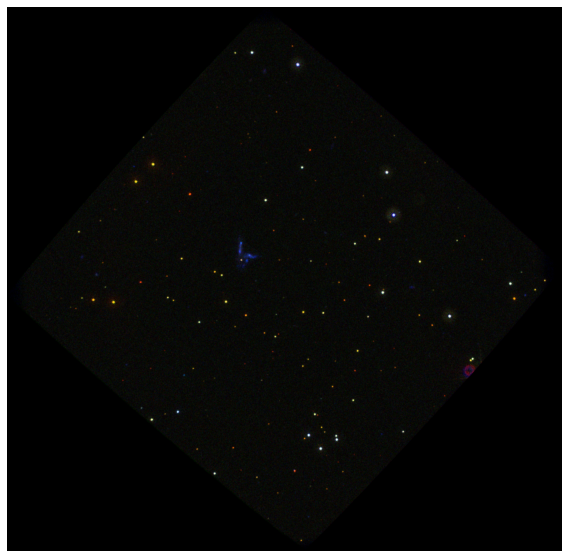

SN pixel coords: x=590.4, y=765.3
Image shape: (1378, 1406)
RA: 114.18028111558874
Dec: 74.45113169649346
sn_coord: <SkyCoord (ICRS): (ra, dec) in deg
    (114.18028112, 74.4511317)>


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 55649.074167 from DATE-OBS.
Set MJD-END to 55649.075162 from DATE-END'. [astropy.wcs.wcs]


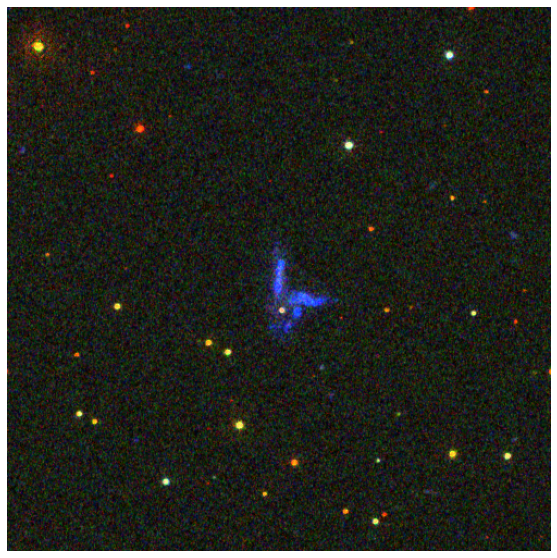

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 55615.341655 from DATE-OBS.
Set MJD-END to 55615.342581 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 55615.335000 from DATE-OBS.
Set MJD-END to 55615.335914 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 55615.342627 from DATE-OBS.
Set MJD-END to 55615.350000 from DATE-END'. [astropy.wcs.wcs]


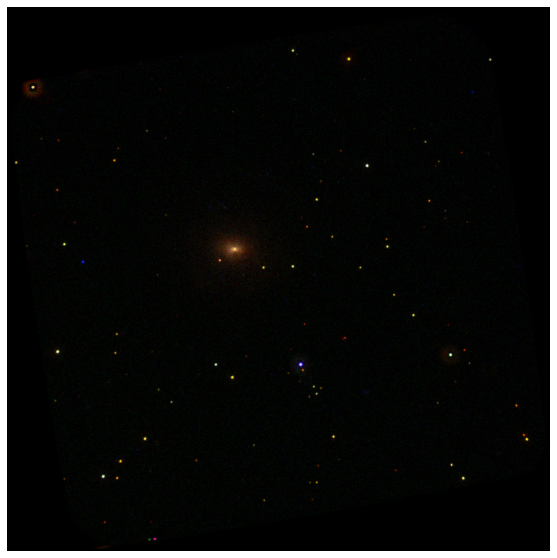

SN pixel coords: x=471.7, y=625.5
Image shape: (1129, 1127)
RA: 133.90898099088375
Dec: 78.22329969426394
sn_coord: <SkyCoord (ICRS): (ra, dec) in deg
    (133.90898099, 78.22329969)>


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 55615.341655 from DATE-OBS.
Set MJD-END to 55615.342581 from DATE-END'. [astropy.wcs.wcs]


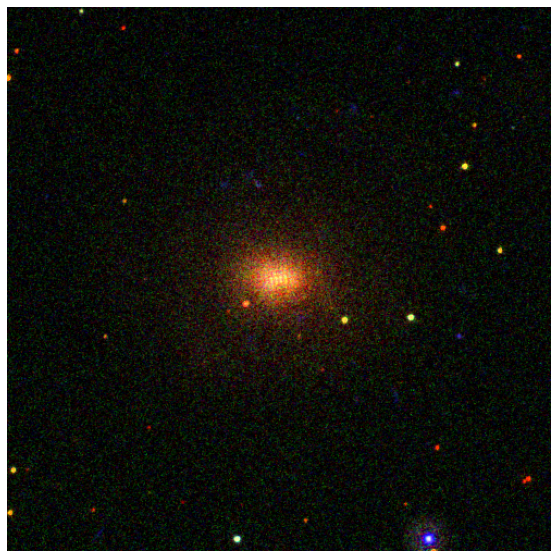

In [16]:
#making the pretty picture after downloading images

for sn, obsID in SNlist.items():
    #for m2
    bluehdu = fits.open(f"sn_pp_data/sw{obsID}um2_sk.img")[1]
    bluehead = bluehdu.header
    blueHDUdata = bluehdu.data

    #for uu
    greenhdu = fits.open(f"sn_pp_data/sw{obsID}uuu_sk.img")[1]
    greenhead = greenhdu.header
    greenHDUdata = greenhdu.data

    #for vv 
    redhdu = fits.open(f"sn_pp_data/sw{obsID}uvv_sk.img")[1]
    redhead = redhdu.header
    redHDUdata = redhdu.data

    #normalizing:
    bdataNorm = blueHDUdata/bluehead['EXPOSURE'] *15
    gdataNorm = greenHDUdata/greenhead['EXPOSURE']
    rdataNorm = redHDUdata/redhead['EXPOSURE']
    
    #ref. image
    refWCS = WCS(redhead)
    refShape = rdataNorm.shape
    rdata= rdataNorm

    #project
    #,_ ignores second variable bc reproj returns 2
    gdata, _ = reproject_interp((gdataNorm, greenhead), refWCS, shape_out=refShape)
    bdata, _ = reproject_interp((bdataNorm, bluehead), refWCS, shape_out=refShape)
    
    
    #clean up bg
    rdata = subtract_background(rdata)
    gdata = subtract_background(gdata)
    bdata = subtract_background(bdata)
    
    ######
    
    #asinh shows better images
    norm = ImageNormalize(stretch=AsinhStretch(a=0.0099999))  
    # apply to each band
    r_n = norm(rdata)
    g_n = norm(gdata)
    b_n = norm(bdata)
    
    #rgb = np.dstack([r_n, g_n, b_n])
    rgb = make_lupton_rgb(r_n,g_n,b_n, Q=0.1, stretch=.45, filename=f"{sn}_rgb_asinhexp.png")
    plt.figure(figsize=(10,10))
    plt.imshow(rgb, origin='lower')
    plt.axis('off')
    plt.show()
    
    ######
    #zoom into image +save that
    
    #getting SN coordinates
    response = urlopen(f"https://blast.scimma.org/api/transient/get/{sn}?format=json")
    data = json.loads(response.read())

    RA = safe_get(data, "host_ra_deg")
    DEC = safe_get(data, "host_dec_deg")

    sn_coord = SkyCoord(RA, DEC, unit=(u.deg, u.deg))  # example: SNF20080514-002

    
    x, y = skycoord_to_pixel(sn_coord, refWCS)

    print(f"SN pixel coords: x={x:.1f}, y={y:.1f}")
    print(f"Image shape: {r_n.shape}")

    # get the WCS for your image
    wcs = WCS(redhead) 

    print("RA:", RA)
    print("Dec:", DEC)
    print("sn_coord:", sn_coord)

    # create the cutout
    size = (500,500)  # (y,x)
    r_cut = Cutout2D(r_n, sn_coord, size=size, wcs=refWCS)
    g_cut = Cutout2D(g_n, sn_coord, size=size, wcs=refWCS)
    b_cut = Cutout2D(b_n, sn_coord, size=size, wcs=refWCS)

    #print img +save
    rgb = make_lupton_rgb(r_cut.data, g_cut.data, b_cut.data, Q=2, stretch=0.15, filename=f"{sn}_rgb_asinh_CUT.png")
    plt.figure(figsize=(10,10))
    plt.imshow(rgb, origin='lower')
    plt.axis('off')
    plt.show()